# **Урок 9**. SORT it out

Сегодня будем разбираться с алгоритмами трекинга, а именно с основой основ — [SORT](https://arxiv.org/pdf/1602.00763.pdf).

Его реализацию всегда берут из [оригинального репозитория](https://github.com/abewley/sort/tree/master), где он написал ровно в одном скрипте — `sort.py`.

Мы поступим так же.

## **План**

1. Разбираемся в `SORT`-е:

    1.1 Теория по фильтру Калмана
    
    1.2 Шаги работы фильтра
    
    1.3 Смотрим код фильтра Калмана
    
    1.4 Разбираем фазу ассоциации
    
    1.5 Смотрим на код самого `SORT`
    
2. Используем `SORT` по назначению — делаем трекинг для людей на видео

## **1. Разбираемся в SORT-e**

In [ ]:
# Именно в этом пакете живет фильтр Калмана, ставим его
%pip install filterpy

In [ ]:
import os
import glob
import argparse
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from time import time
from skimage import io
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment

np.random.seed(0)

Заводим вспомогательные функции:

In [ ]:
# Тут спрятан Венгерский алгоритм
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html
# https://habr.com/ru/articles/422009/ — подробный пример работы алгоритма на Хабре
def linear_assignment(cost_matrix):
    x, y = linear_sum_assignment(cost_matrix)
    return np.array(list(zip(x, y)))


# Считаем матрицу IoU между двумя листами — gt и dets
def iou_batch(bb_test, bb_gt):
    """
    bb_test - list of detections [x1, y1, x2, y2]
    bb_gt - list of gts [x1, y1, x2, y2]
    """
    bb_gt = np.expand_dims(bb_gt, 0)
    bb_test = np.expand_dims(bb_test, 1)

    xx1 = np.maximum(bb_test[..., 0], bb_gt[..., 0])
    yy1 = np.maximum(bb_test[..., 1], bb_gt[..., 1])
    xx2 = np.minimum(bb_test[..., 2], bb_gt[..., 2])
    yy2 = np.minimum(bb_test[..., 3], bb_gt[..., 3])
    w = np.maximum(0., xx2 - xx1)
    h = np.maximum(0., yy2 - yy1)
    wh = w * h

    ious = wh / ((bb_test[..., 2] - bb_test[..., 0]) * (bb_test[..., 3] - bb_test[..., 1])
        + (bb_gt[..., 2] - bb_gt[..., 0]) * (bb_gt[..., 3] - bb_gt[..., 1]) - wh)
    return (ious)


# [x1, y1, x2, y2] -> [сx, сy, s, r]
def convert_bbox_to_z(bbox):
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    x = bbox[0] + w/2.
    y = bbox[1] + h/2.
    s = w * h
    r = w / float(h)
    return np.array([x, y, s, r]).reshape((4, 1))


# [сx, сy, s, r] -> [x1, y1, x2, y2]
def convert_x_to_bbox(x, score=None):
    w = np.sqrt(x[2] * x[3])
    h = x[2] / w

    if score == None:
        return np.array([x[0]-w/2, x[1]-h/2, x[0]+w/2, x[1]+h/2]).reshape((1,4))

    return np.array([x[0]-w/2, x[1]-h/2, x[0]+w/2, x[1]+h/2, score]).reshape((1,5))

### **1.1 Теория по фильтру Калмана**

Много материала для этого раздела брала из [хорошей статьи на Хабре](https://habr.com/ru/companies/singularis/articles/516798/), а также из [этой статьи про DeepSORT](https://www.thinkautonomous.ai/blog/computer-vision-for-tracking/#kf).

Напомню вводные про фильтр: 

у нас есть некоторая дискретная модель движения нашего объекта (которая неидеально описывается линейными законами) и есть показатели датчика, который замеряет положение нашего объекта (тоже с ошибкой). В нашем случае таким датчиком будет детектор для объектов. 

Мы хотим использовать наши знания о характере движения и шумные замеры с датчика, и в итоге получить наилучшие оценки истинных координат.

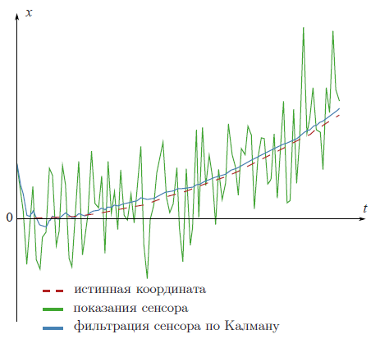

Как это сделать?

#### **1.1.1 Вектор состояния**

Для начала необходимо задать вектор состояния нашего объекта. 

В `SORT` состояние `bbox`-а внутри фильтра Калмана описывается вектором из 7 координат:

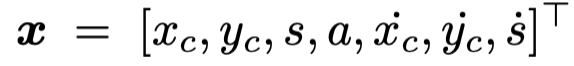



При инициализации скорости в нём равны 0, остальные значения соответствуют настоящим от `bbox`-а. Позже скорости посчитаем (вернее, фильтр нам посчитает), когда наберём ещё детекций.

Для работы с этим состоянием у нас будут матрицы $F$ и $H$.

#### **1.1.2 $F$ — матрица процесса**






Она просто задаёт правила, по которым мы из $x_t$ получаем $x_{t+1}$

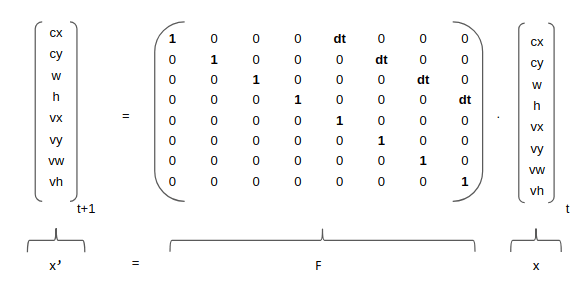

(Тут указан чуть другой вектор состояния, такой тоже бывает в реализациях трекинга, и работает он, кстати, лучше)

#### **1.1.3 $H$ — матрица наблюдения**



По сути, она просто подбивает нам размерности между вектором измерений (а измерений у нас 4 — это $x, y, w, h$) и размерностью состояния системы.

Если у нас $Z$ — вектор измерений:

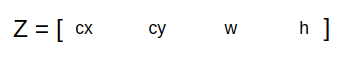

А всего в системе было бы 8 параметров, то $H$ выглядела бы так:

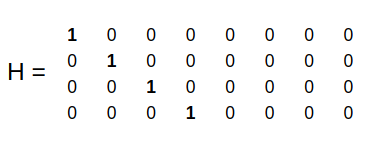

Мы понимаем и принимаем, что наша модель описания состояния неидеальна, поэтому заводим несколько ковариационных матриц, которые отвечают за неопределённость нашего процесса — $P$, $Q$, $R$.

#### **1.1.4 $P$ — ковариационная матрица состояния**



Ковариационная матрица — это многомерный аналог дисперсии, для случая, когда у нас не одна случайная величина, а случайный вектор. Ковариационные матрицы — симметричные квадратные, на главной диагонали у них располагаются дисперсии элементов вектора. Остальные элементы матрицы — ковариации между компонентами вектора. Ковариация показывает, насколько переменные зависят друг от друга.

Эта матрица определяет «уверенность» фильтра в оценке переменных состояния. Алгоритм самостоятельно обновляет эту матрицу в процессе работы. Однако нам нужно установить начальное состояние, вместе с исходным предположением о векторе состояния. Обычно мы не знаем как друг с другом связаны наши переменные в самом начале, — поэтому задаём её просто диагональной. Чем больше значения, тем больше мы не уверены.

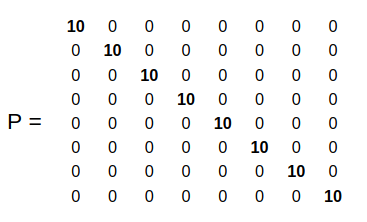

#### **1.1.5 $R$ — ковариационная матрица шума измерений**



По сути, тут мы закладываем погрешность детектора в его «измерениях» - если бы мы работали с каким-то прибором, тут бы была диагональная матрица со значениями дисперсии, которая свойственна данному прибору. Мы тут зададим возможные отклонения в пикселях.

Если у нас вектор измерения — это $x = [cx, cy, w, h]$, то логично предположить, что в ширине/высоте мы можем побольше ошибаться, чем в положении центра, и выразить эту неопределённость вот так:

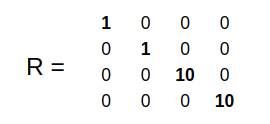

#### **1.1.6 $Q$ — ковариационная матрица ошибки модели**



Каждый раз, когда фильтр предсказывает состояние системы, используя модель процесса, он увеличивает неуверенность в оценке вектора состояния. Для одномерного случая формула выглядит приблизительно следующим образом:

image.png

Если установить очень маленькое значение $Q$, то этап предсказания будет слабо увеличивать неопределённость оценки. Это означает, что мы считаем, что наша модель точно описывает процесс.

Если же установить большое значение $Q$, то этап предсказания будет сильно увеличивать неопределённость оценки. Таким образом мы показываем, что модель может содержать неточности или неучтённые факторы.

Значения, конечно, можно подбирать под задачу, но обычно они тут очень небольшие.

Важно, что эта матрица указывает, на какие переменные состояния будут в первую очередь влиять ошибки модели и неучтённые факторы.

### **1.2. Шаги работы фильтра**

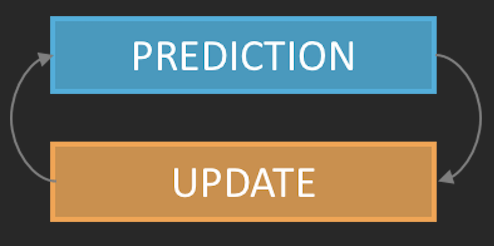

#### **1.2.1 Шаг предикта**

Выглядит формульно так (очень приятно):

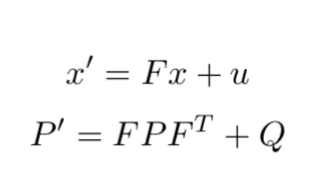

**UPD**. Вектор $u$ тут отвечает за внешнее воздействие, и он должен умножаться ещё на соответственную матрицу $B$. Мы её считаем нулевой, так что этот член отпадает.

#### **1.2.2 Между шагами**



Теперь у нас есть предикты, есть детекции, мы между ними построили соответствие с помощью Венгерского алгоритма и очень рады.

Если для трека мы не нашли подкрепляющего бокса (и нам ещё не пора убивать трек), то мы просто будем делать дальше предикты в соответствии с нашим состоянием фильтра.

Если же мы подкрепляющий бокс нашли, то придётся переходить к шагу апдейта — обновлять наше понимание характера движения трека и считать между предиктом и боксом некоторое золотое среднее.

#### **1.2.3 Шаг апдейта**

Выглядит вот так (очень неприятно):

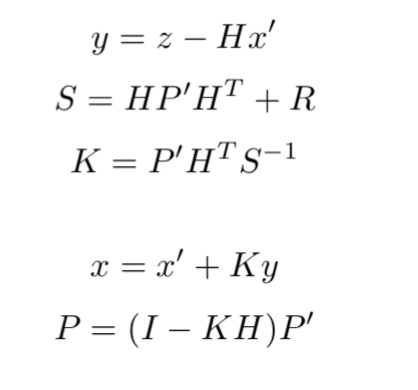

#### **1.2.4 Что тут вообще происходит?**

1. Сперва считаем $y$ — это зазор между нашим предсказанием положения ($x'$, то есть той его частью, что за координаты отвечает) и предсказанным детектором боксом $Z$.

2. Тут (во (2) и (3) формулах) мы считаем матрицу усиления (`gain`) Калмана $K$.


3. Разницу $y$ из п. 1 мы будем взвешивать с помощью матрицы Калмана $K$ и суммировать с этим самым $x'$ в (4) формуле, то есть находить золотую середину, ну или просто сглаживать предсказание детектора.

4. $P$ тоже обновим с помощью найденного $K$.  




В [source-code](https://filterpy.readthedocs.io/en/latest/_modules/filterpy/kalman/kalman_filter.html#KalmanFilter) происходит всё ровно то же самое.

Скорость здесь обновляется в $x = x' + Ky$:
- $x$ и $x'$ — это полноценные вектора состояния (у нас размерности 7)
- $y$ — вектор разницы наблюдений размерности 4
- $K$ — матрица Калмана размера 7x4

То есть в итоговом $x$ у нас обновятся все координаты (и скорости тоже, здесь это и происходит).

#### **1.2.5 А почему оно так происходит?**

Математические раскладки для одномерного случая есть в [ещё одном посте с Хабра](https://habr.com/ru/articles/166693/).

Вывод получается из того, что мы решаем оптимизационную задачу по минимизации мат. ожидания ошибки предсказания $x^{opt}$:

Вот ошибка:

image.png

image.png

А вот что хотим сделать:

image.png

image.png

Если мы посчитаем его производную и приравняем её к нулю, то получим формулу для $K^{k+1}$:

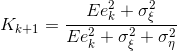

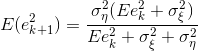

Ну всё, у нас есть итерационная формула для вычисления $K$, с ней и будем считать $x_{k+1}^{opt}$.

### **1.3 Смотрим код фильтра Калмана**

In [ ]:
class KalmanBoxTracker(object):
    """
    This class represents the internal state of individual tracked objects observed as bbox.
    """
    count = 0
    def __init__(self, bbox):
        """
        Initialises a tracker using initial bounding box.
        """
        # задаём матрицы для модели с постоянной скоростью
        # dim_x — столько у нас параметров для отслеживания
        # dim_z — столько у нас измеряемых параметров
        self.kf = KalmanFilter(dim_x=7, dim_z=4)

        # это матрицы, описывающие движение
        # матрица процесса
        self.kf.F = np.array([[1,0,0,0,1,0,0],
                              [0,1,0,0,0,1,0],
                              [0,0,1,0,0,0,1],
                              [0,0,0,1,0,0,0],
                              [0,0,0,0,1,0,0],
                              [0,0,0,0,0,1,0],
                              [0,0,0,0,0,0,1]])

        # матрица наблюдения
        self.kf.H = np.array([[1,0,0,0,0,0,0],
                              [0,1,0,0,0,0,0],
                              [0,0,1,0,0,0,0],
                              [0,0,0,1,0,0,0]])

        # это матрицы, отвечающие за неопределенность
        # R — матрица шума измерений (dim_z x dim_z)
        self.kf.R[2:,2:] *= 10.

        # P — матрица неопределенности состояния (dim_x x dim_x)
        self.kf.P[4:,4:] *= 1000. # give high uncertainty to the unobservable initial velocities
        self.kf.P *= 10.

        # Q — матрица ошибки модели (dim_x x dim_x)
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01

        # начальное состояние
        self.kf.x[:4] = convert_bbox_to_z(bbox)
        self.time_since_update = 0

        self.id = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1

        self.history = []
        self.hits = 0  # это число подкреплений
        self.hit_streak = 0 # а это длина текущей серии подкреплений
        self.age = 0


    # метод для апдейта внутреннего состояния
    def update(self, bbox):
        """
        Updates the state vector with observed bbox.
        """
        self.time_since_update = 0
        self.history = []
        self.hits += 1
        self.hit_streak += 1
        self.kf.update(convert_bbox_to_z(bbox))


    # метод для предикта бокса
    def predict(self):
        """
        Advances the state vector and returns the predicted bounding box estimate.
        """
        if self.kf.x[6] + self.kf.x[2] <= 0:
            self.kf.x[6] *= 0.0

        self.kf.predict()
        self.age += 1

        # если у нас подкрепления не подряд, то зануляем
        if self.time_since_update > 0:
            self.hit_streak = 0

        self.time_since_update += 1
        self.history.append(convert_x_to_bbox(self.kf.x))

        return self.history[-1]

    def get_state(self):
        """
        Returns the current bounding box estimate.
        """
        return convert_x_to_bbox(self.kf.x)

Вот и всё, что живёт внутри Калман-трекера, — он предсказывает, апдейтит предсказание и своё состояние, ну и может показать вам своё состояние текущее.

Остались ещё две важные составляющие — стадия ассоциации детекций с треками, а также жизненный цикл рождения и умирания для треков.

На них и посмотрим дальше.

### **1.4 Разбираем фазу ассоциации**

Это всё обёртки логики вокруг Венгерского алгоритма и раскладывание всех по спискам.

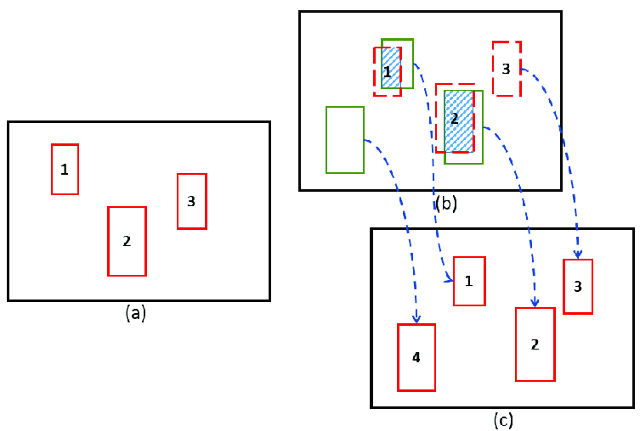

Во время фазы ассоциации нам надо сматчить один к одному предсказания фильтра Калмана на N+1 кадре и предсказания детектора объектов на этом кадре.

In [ ]:
def associate_detections_to_trackers(detections, trackers, iou_threshold = 0.3):
    """
    Assigns detections to tracked object (both represented as bounding boxes)

    Returns 3 lists of matches, unmatched_detections and unmatched_trackers
    """
    # если у нас живых треков нет вообще, то и ассоциировать нечего
    if len(trackers) == 0:
        return np.empty((0, 2), dtype=int), np.arange(len(detections)), np.empty((0,5),dtype=int)

    # считаем матрицу попарных IoU
    iou_matrix = iou_batch(detections, trackers)

    # а так мы проверили, что у нас детекции есть
    if min(iou_matrix.shape) > 0:
        # смотрим, где у нас валидные пересечения выше порога
        a = (iou_matrix > iou_threshold).astype(np.int32)
        if (a.sum(1).max() == 1) and (a.sum(0).max() == 1): # если у нас нет конфликтов, и все сматчились 1 к 1, то и назначать нечего
            matched_indices = np.stack(np.where(a), axis=1) # так и берём, как сматчились
        else:
            matched_indices = linear_assignment(-iou_matrix) # -iou_matrix = cost_matrix
    else:
        matched_indices = np.empty(shape=(0,2)) # и если их нет, то нечего ассоциировать

    # собираем неприкаянных
    # эти детекции должны будут инициировать новые треки
    unmatched_detections = []
    for d, det in enumerate(detections):
        if d not in matched_indices[:, 0]:
            unmatched_detections.append(d)

    # эти трекеры пока поживут на Калмане или умрут
    unmatched_trackers = []
    for t, trk in enumerate(trackers):
        if (t not in matched_indices[:,1]):
            unmatched_trackers.append(t)

    # Мы могли в ходе венгерского алгоритма создать пару с маленьким iou
    # потому что это был лучший выбор
    # но мы такие детекции всё равно завтра не пропустим
    matches = []
    for m in matched_indices:
        if iou_matrix[m[0], m[1]] < iou_threshold:
            unmatched_detections.append(m[0])
            unmatched_trackers.append(m[1])
        else:
            matches.append(m.reshape(1,2))

    if len(matches) == 0:
        matches = np.empty((0, 2), dtype=int)
    else:
        matches = np.concatenate(matches, axis=0)

    # возвращаем все матчи, а также неприкаянных
    return matches, np.array(unmatched_detections), np.array(unmatched_trackers)

### **1.5 Смотрим на код самого SORT**

Ну а тут решаются вопросы жизненного цикла треков.

In [ ]:
class Sort(object):
    def __init__(self, max_age=1, min_hits=3, iou_threshold=0.3):
        self.max_age = max_age  # длина хвоста без подкрепления детекциями
        self.min_hits = min_hits  # минимальное число детекций, нужное для инициализации трека
        self.iou_threshold = iou_threshold  # порог для матчинга детекций и предиктов трекера
        self.trackers = [] # тут живут все наши трекеры — для каждого трека свой!
        self.frame_count = 0

    def update(self, dets=np.empty((0, 5))):
        """
        Params:
          dets - a numpy array of detections in the format [[x1,y1,x2,y2,score],[x1,y1,x2,y2,score],...]

        Requires: this method must be called once for each frame even with empty detections (use np.empty((0, 5)) for frames without detections).
        Returns the a similar array, where the last column is the object ID.

        NOTE: The number of objects returned may differ from the number of detections provided.
        """
        self.frame_count += 1

        # собираем в trks предикты от всех фильтров для текущего фрейма
        trks = np.zeros((len(self.trackers), 5))
        to_del = []
        ret = []

        for t, trk in enumerate(trks):
            pos = self.trackers[t].predict()[0]
            trk[:] = [pos[0], pos[1], pos[2], pos[3], 0]
            if np.any(np.isnan(pos)):
                to_del.append(t)

        trks = np.ma.compress_rows(np.ma.masked_invalid(trks))
        for t in reversed(to_del):
            self.trackers.pop(t)

        # матчим dets и trks
        matched, unmatched_dets, unmatched_trks = associate_detections_to_trackers(dets, trks, self.iou_threshold)

        # все сматченные трекеры проходят фазу апдейта
        for m in matched:
            self.trackers[m[1]].update(dets[m[0], :])

        # все несматченные детекции получают по собственному трекеру
        for i in unmatched_dets:
            trk = KalmanBoxTracker(dets[i,:])
            self.trackers.append(trk)

        # пробежимся по трекерам, посмотрим, как дела
        # и соберём массив ответов по текущему фрейму
        i = len(self.trackers)
        for trk in reversed(self.trackers):
            d = trk.get_state()[0]
            # если только что было подкрепление, и у нас для него достаточно подкреплений подряд, ну либо мы в самом начале видео и не могли подкреплений набрать ещё
            # то мы отдаём это предсказание в качестве ответа
            # (тут, конечно, странно, что мы ничего не отдаём из unmatched_trks)
            if (trk.time_since_update < 1) and (trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
                ret.append(np.concatenate((d, [trk.id+1])).reshape(1,-1)) # +1 as MOT benchmark requires positive

            # тут какие-то вообще не изящные решения для выбора индексов, ну ладно
            i -= 1

            # если трекер уже слишком долго без подкрепления, он умирает
            if trk.time_since_update > self.max_age:
                self.trackers.pop(i)

        if len(ret) > 0:
            return np.concatenate(ret)

        return np.empty((0,5))

Вот такой вот SORT.

### **Резюме**

В этом разделе мы:

- Рассмотрели все объекты, которые работают в фильтре Калмана
- Вспомнили, какие шаги есть в трекере
- Разобрались, как все эти шаги реализуются в коде
- Собрали код всего трекера `SORT`

## **2. Используем `SORT` по назначению — делаем трекинг для людей на видео**

In [ ]:
import cv2
import torch
import random

from PIL import Image
from torchvision import models
from torchvision.transforms import v2
from matplotlib import pyplot as plt

Для тестиков будем использовать видео из МОТ16 challenge: [MOT16-11](https://drive.google.com/file/d/17vO5fNgtNXW2aLwyBoGlOz3LeVsXKHN5/view?usp=sharing).

А также картинку с пёселем для отладки детектора.

Так как нам всё лень, возьмём детектор из [`torchvision.models`](https://pytorch.org/vision/stable/models.html#object-detection-instance-segmentation-and-person-keypoint-detection). Можно взять любой на свой вкус, например, `SSD320` c мобильным бэкбоном.

In [ ]:
model = models.detection.ssdlite320_mobilenet_v3_large(weights='DEFAULT')
model.eval()
model.cuda()

Детектор обучен на `COCO`, а значит, в нем 92 класса. 

In [ ]:
colors = [(random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) for j in range(500)]

font = cv2.FONT_HERSHEY_SIMPLEX

# отсюда https://github.com/amikelive/coco-labels/blob/master/coco-labels-paper.txt
coco_labels = ('background', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',  'train', 'truck', 'boat', 'traffic light',
              'fire hydrant', 'street sign', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
              'elephant', 'bear', 'zebra', 'giraffe', 'hat', 'backpack', 'umbrella', 'shoe', 'eye glasses', 'handbag', 'tie', 'suitcase', 'frisbee',
              'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
              'plate', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
              'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'mirror',
              'dining table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
              'toaster', 'sink', 'refrigerator', 'blender', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'hair brush')

In [ ]:
len(coco_labels)

In [ ]:
img = cv2.imread('dog.jpeg')

In [ ]:
plt.imshow(img[:, :, ::-1])

In [ ]:
# Мы тут задаём самый примитивный трансформ, так как целевой трансформ уже вшит в детектор
transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(dtype=torch.float32, scale=True),
        ])

def prepare_img(img):
    img = Image.fromarray(img)
    tensor = transform(img)
    tensor = torch.unsqueeze(tensor, 0)
    return tensor.cuda()


tensor = prepare_img(img)
result = model(tensor)[0]

In [ ]:
# Посмотрим, что выдаст детектор, можем тут поиграться со скором отрисовки
img = cv2.imread('dog.jpeg')

boxes = result['boxes'].data.cpu()
scores = result['scores'].data.cpu()
labels = result['labels'].data.cpu()

for (bb, scr, lbl) in zip(boxes, scores, labels):
    if scr > 0.4:
        x1, y1, x2, y2 = bb
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (colors[lbl % len(colors)]), 3)
        cv2.putText(img, coco_labels[lbl], (int(x1), int(y1)-10), font, 1, (colors[lbl % len(colors)]), 2, cv2.LINE_AA)

plt.imshow(img[:, :, ::-1])

Детектор зафиксировали, давайте теперь с видео разберёмся.

In [ ]:
# Заводим captures для входящего и исходящего видео
video_path = './MOT16-11.webm' # это видео мы читаем
video_out_path = './MOT16-11_ssd.mp4' # сюда сохраним отрисованный результат

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read() # получаем статус и сам следующий фрейм

cap_out = cv2.VideoWriter(video_out_path, 
                          cv2.VideoWriter_fourcc(*'MP4V'), 
                          cap.get(cv2.CAP_PROP_FPS),
                          (frame.shape[1], frame.shape[0]))

In [ ]:
# Создаём трекер 
tracker = Sort(max_age=15, min_hits=3, iou_threshold=0.3)

# Задаем порог для детектора
score_threshold = 0.4

In [ ]:
%%time

# теперь погнали читать кадры из видео (пока они есть),
# и прогонять на них детектор и трекер
while ret:
    tensor = prepare_img(frame)
    result = model(tensor)[0] # вот детектор зовем

    # достаем из результатов нужные листики
    detections = []
    boxes = result['boxes'].data.cpu()
    scores = result['scores'].data.cpu()
    labels = result['labels'].data.cpu()

    for (bb, scr, lbl) in zip(boxes, scores, labels):
        if (scr > score_threshold) and (lbl == 1):
            x1, y1, x2, y2 = bb
            detections.append([int(x1), int(y1), int(x2), int(y2), scr.item()])

    detections = np.array(detections)

    if len(detections) == 0:
        detections = np.empty((0, 5))

    res = tracker.update(detections) # вот так мило одной строчкой трекер добавим

    # забираем и отрисовываем результаты трекера
    for id_res in res:
        x1, y1, x2, y2 = id_res[:-1]
        track_id = id_res[-1].astype(int)
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (colors[track_id % len(colors)]), 3)
        cv2.putText(img, f'id: {track_id}', (int(x1), int(y1)-10), font, 1, (colors[lbl % len(colors)]), 2, cv2.LINE_AA)

    cap_out.write(frame)
    ret, frame = cap.read()

cap.release()
cap_out.release()

Посмотрим видео, которое у нас получилось!

Итак, задача, кажется, решается, но выглядит не особо круто — много пропущенных людей, да и локализация хромает. 

Всё дело тут в слабом детекторе — никакого трекер его проблем не сможет полностью нивелировать. 

Давайте попробуем проделать то же самое с `Faster R-CNN` c хорошим бэкбоном.

In [ ]:
model = models.detection.fasterrcnn_resnet50_fpn_v2(weights='DEFAULT')
model.eval()
model.cuda()

Подберём снова на пёселях порог:

In [ ]:
img = cv2.imread('dog.jpeg')
tensor = prepare_img(img)
result = model(tensor)[0]

boxes = result['boxes'].data.cpu()
scores = result['scores'].data.cpu()
labels = result['labels'].data.cpu()

for (bb, scr, lbl) in zip(boxes, scores, labels):
    if scr > 0.85:
        x1, y1, x2, y2 = bb
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (colors[lbl % len(colors)]), 3)
        cv2.putText(img, coco_labels[lbl], (int(x1), int(y1)-10), font, 1, (colors[lbl % len(colors)]), 2, cv2.LINE_AA)

plt.imshow(img[:, :, ::-1])

In [ ]:
video_out_path = './MOT16-11_faster_rcnn.mp4'

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()

cap_out = cv2.VideoWriter(video_out_path, 
                          cv2.VideoWriter_fourcc(*'MP4V'), 
                          cap.get(cv2.CAP_PROP_FPS),
                          (frame.shape[1], frame.shape[0]))

tracker = Sort(max_age=15, min_hits=3, iou_threshold=0.3)
score_threshold = 0.85

In [ ]:
%%time

while ret:
    tensor = prepare_img(frame)
    result = model(tensor)[0]

    detections = []
    boxes = result['boxes'].data.cpu()
    scores = result['scores'].data.cpu()
    labels = result['labels'].data.cpu()

    for (bb, scr, lbl) in zip(boxes, scores, labels):
        if (scr > score_threshold) and (lbl == 1):
            x1, y1, x2, y2 = bb
            detections.append([int(x1), int(y1), int(x2), int(y2), scr.item()])

    detections = np.array(detections)

    if len(detections) == 0:
        detections = np.empty((0, 5))

    res = tracker.update(detections)

    for id_res in res:
        x1, y1, x2, y2 = id_res[:-1]
        track_id = id_res[-1].astype(int)
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (colors[track_id % len(colors)]), 3)
        cv2.putText(img, f'id: {track_id}', (int(x1), int(y1)-10), font, 1, (colors[lbl % len(colors)]), 2, cv2.LINE_AA)

    cap_out.write(frame)
    ret, frame = cap.read()

cap.release()
cap_out.release()

Снова смотрим на результат. 

Как мы и ожидали, выглядит уже намного лучше, очень даже впечатляюще!

Итак, мы
- попробовали `SSD` и `Faster R-CNN` в качестве детекторов
- прикрутили к ним одной строчкой трекер `SORT`
- качественно (экспертно на глаз) сравнили результаты и увидели, что задача действительно решается, с `Faster R-CNN` причём намного лучше

А мы давайте подведём итоги.

## **Итоги**

В этой практике мы:

- разобрались с теорией работы фильтра Калмана
- разобрались с кодом `SORT`-трекера
- одной строчкой прикрутили обработку треков к детектору
- получили качественные результаты для задачи трекинга с двумя детекторами
- порадовались качеству результатов :)

Ай да мы!

Вот и всё про трекинг.
Дальнейшее улучшение этого алгоритма — [DeepSORT](https://github.com/nwojke/deep_sort).

Код там уже заметно более зрелый, но главное отличие — другая конструкция `cost_matrix`, которую мы используем в Венгерском алгоритме.

Советую покопаться, если вам интересно :)

See you!